In [1]:
import networkx as nx
from bmg_Tony import bmg

In [2]:
G = nx.DiGraph()
G.add_node("y", reconc='red')
G.add_node("y1", reconc='red')
G.add_node("y2", reconc='red')
G.add_node("x", reconc='green')
G.add_edge("rho", "Pxy")
G.add_edge("rho", "Pxy1")
G.add_edge("rho", "Pxy2")
G.add_edge("Pxy", "y")
G.add_edge("Pxy", "x")
G.add_edge("Pxy", "Qxy2")
G.add_edge("Pxy1", "y1")
G.add_edge("Pxy1", "x")
G.add_edge("Pxy1", "Qxy2") #remove this edge later
G.add_edge("Pxy2", "y2")
G.add_edge("Pxy2", "x")
G.add_edge("Pxy2", "Qxy")
G.add_edge("Qxy", "x")
G.add_edge("Qxy", "y")
G.add_edge("Qxy2", "x")
G.add_edge("Qxy2", "y2")

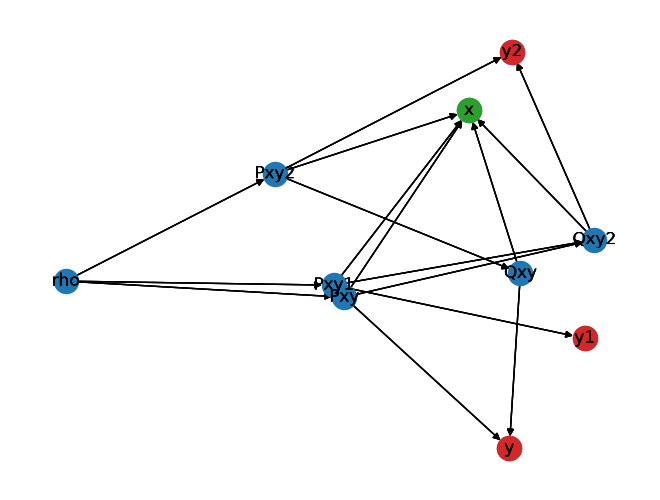

In [3]:
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True)
nx.draw(G, pos, nodelist=["y", "y1", "y2"], node_color="tab:red", with_labels=True)
nx.draw(G, pos, nodelist=["x"], node_color="tab:green", with_labels=True)

In [4]:
BMG_network_tony_weak = bmg(G, mode= 'weak')
BMG_network_tony_strong = bmg(G, mode= 'strong')

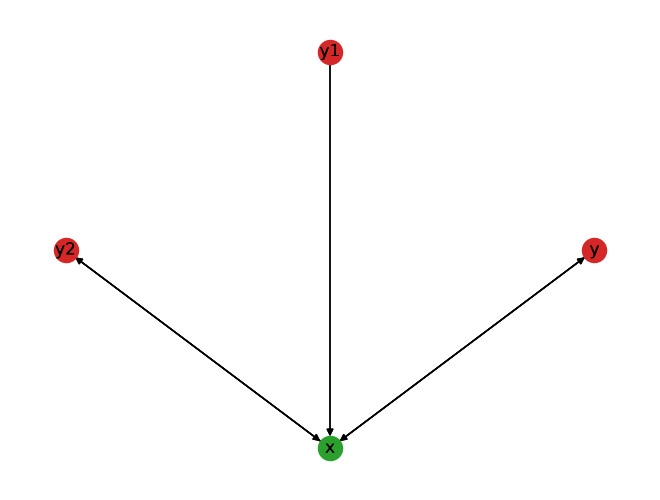

In [5]:
# weak definition
pos = nx.circular_layout(BMG_network_tony_weak)
nx.draw(BMG_network_tony_weak, pos, nodelist=["y", "y1", "y2"], node_color="tab:red", with_labels=True)
nx.draw(BMG_network_tony_weak, pos, nodelist=["x"], node_color="tab:green", with_labels=True)


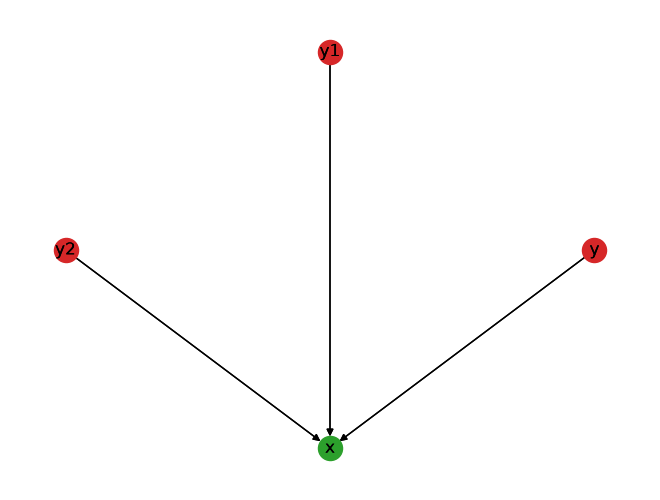

In [6]:
# strong definition
pos = nx.circular_layout(BMG_network_tony_strong)
nx.draw(BMG_network_tony_strong, pos, nodelist=["y", "y1", "y2"], node_color="tab:red", with_labels=True)
nx.draw(BMG_network_tony_strong, pos, nodelist=["x"], node_color="tab:green", with_labels=True)

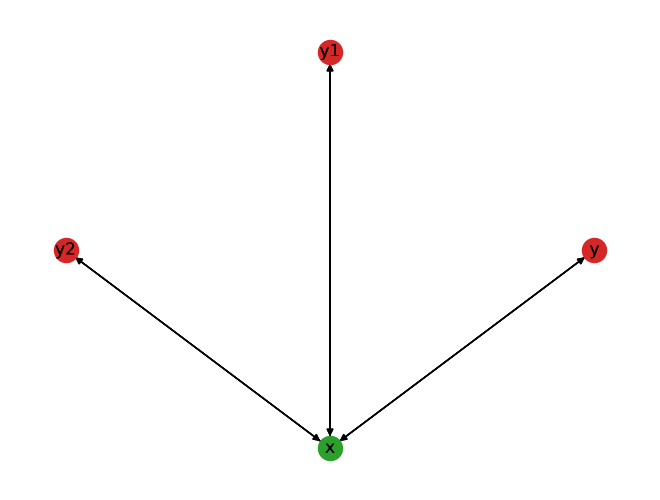

In [7]:
# Results with edge removed
G.remove_edge("Pxy1", "Qxy2") #remove this edge later
BMG_network_tony_weak = bmg(G, mode= 'weak')
pos = nx.circular_layout(BMG_network_tony_weak)
nx.draw(BMG_network_tony_weak, pos, nodelist=["y", "y1", "y2"], node_color="tab:red", with_labels=True)
nx.draw(BMG_network_tony_weak, pos, nodelist=["x"], node_color="tab:green", with_labels=True)


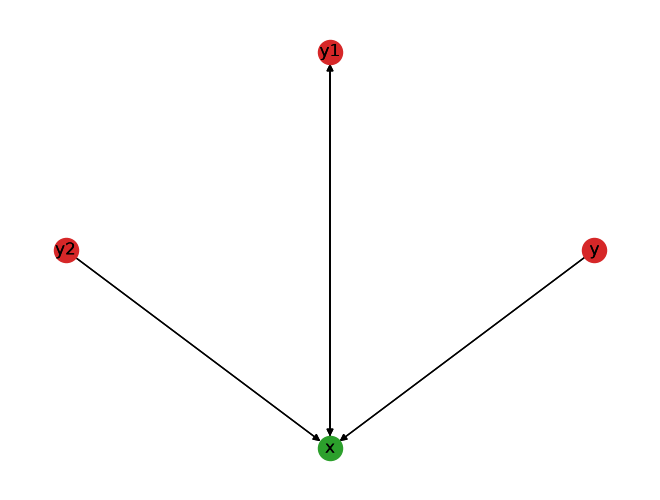

In [8]:
BMG_network_tony_strong = bmg(G, mode= 'strong')
pos = nx.circular_layout(BMG_network_tony_strong)
nx.draw(BMG_network_tony_strong, pos, nodelist=["y", "y1", "y2"], node_color="tab:red", with_labels=True)
nx.draw(BMG_network_tony_strong, pos, nodelist=["x"], node_color="tab:green", with_labels=True)

In [9]:
T = nx.DiGraph()
T.add_nodes_from([("a1", {"reconc": "red"}), ("b1", {"reconc": "blue"}), ("c1", {"reconc": "green"}),
                  ("b2", {"reconc": "blue"}), ("c2", {"reconc": "green"})])
T.add_edges_from([("p", "u"), ("u", "a1"), ("u", "w"), ("w", "b1"), ("w", "c1"), ("p", "v"), ("v", "b2"), ("v", "c2")])

G = nx.DiGraph()
G.add_nodes_from([("a1", {"reconc": "red", 'label': 'a1'}), ("b1", {"reconc": "blue", 'label': 'b1'}), ("c1", {"reconc": "green", 'label': 'c1'}),
                  ("b2", {"reconc": "blue", 'label': 'b2'}), ("c2", {"reconc": "green", 'label': 'c2'})])
G.add_edges_from([("a1", "c1"), ("c1", "a1"), ("b1", "a1"), ("a1", "b1"), ("c2", "a1"), ("b2", "a1"), ("b1", "c1"), ("c1", "b1"),
                  ("b2", "c2"), ("c2", "b2")])

result = bmg(T, mode="strong")

In [10]:
nx.utils.graphs_equal(result, G)

True

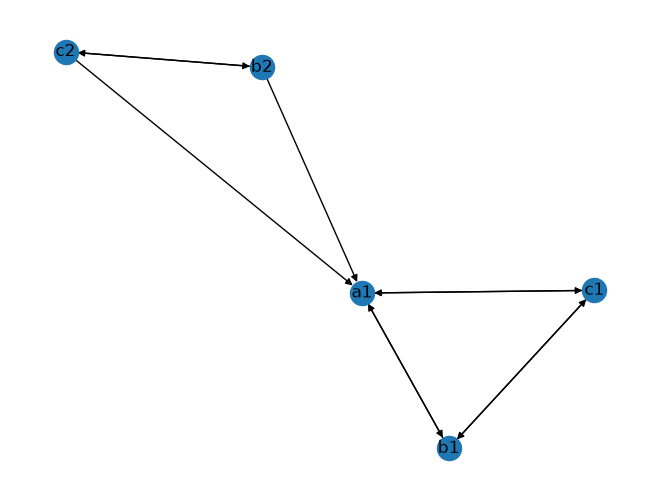

In [11]:
nx.draw(result, with_labels=True)

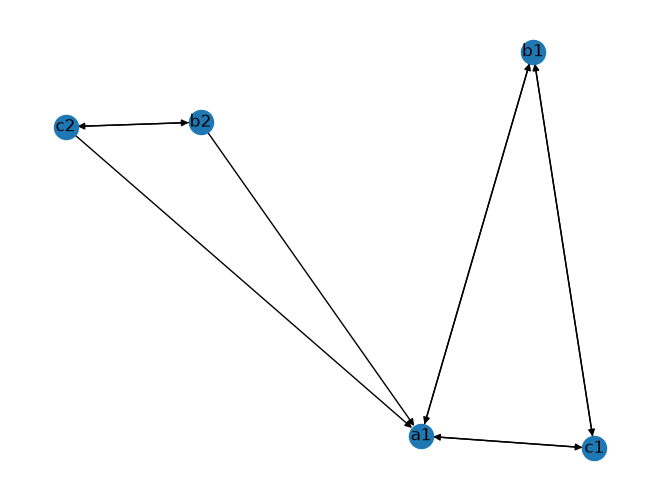

In [12]:
nx.draw(G, with_labels=True)

In [13]:
print(result.nodes(data=True))
print(G.nodes(data=True))

[('a1', {'reconc': 'red', 'label': 'a1'}), ('b1', {'reconc': 'blue', 'label': 'b1'}), ('c1', {'reconc': 'green', 'label': 'c1'}), ('b2', {'reconc': 'blue', 'label': 'b2'}), ('c2', {'reconc': 'green', 'label': 'c2'})]
[('a1', {'reconc': 'red', 'label': 'a1'}), ('b1', {'reconc': 'blue', 'label': 'b1'}), ('c1', {'reconc': 'green', 'label': 'c1'}), ('b2', {'reconc': 'blue', 'label': 'b2'}), ('c2', {'reconc': 'green', 'label': 'c2'})]


In [1]:
# import stuff
import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
import bmg_fun
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
import random
import matplotlib.gridspec as gridspec
from lrt_fun import lrt_from_bmg
import BICcherry
import numpy as np
from bmg_Tony import bmg

In [2]:
# set seed
# Setze den Seed für Pythons Standard-Zufallsfunktionen
random.seed(3)
# Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
np.random.seed(3)

# species tree
S = te.species_tree_n_age(
    4, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
# gene tree
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
)
# prune all loss branches and the planted root
observable_gene_tree = te.prune_losses(T)
#visualize(T, color_dict=gene_colors) 
# get color dicts
species_colors, gene_colors = assign_colors(S, observable_gene_tree)
tree_to_nx = bmg_fun.convert_to_nx(observable_gene_tree)
# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}
# BMGs mit Tonys Funktion
BMG_tree_tony = bmg(tree_to_nx)
thin_BMG, thin_gene_colors = bmg_fun.thinness_graph(BMG_tree_tony, gene_colors_str)



Text(0.5, 1.0, 'Thinness class BMG')

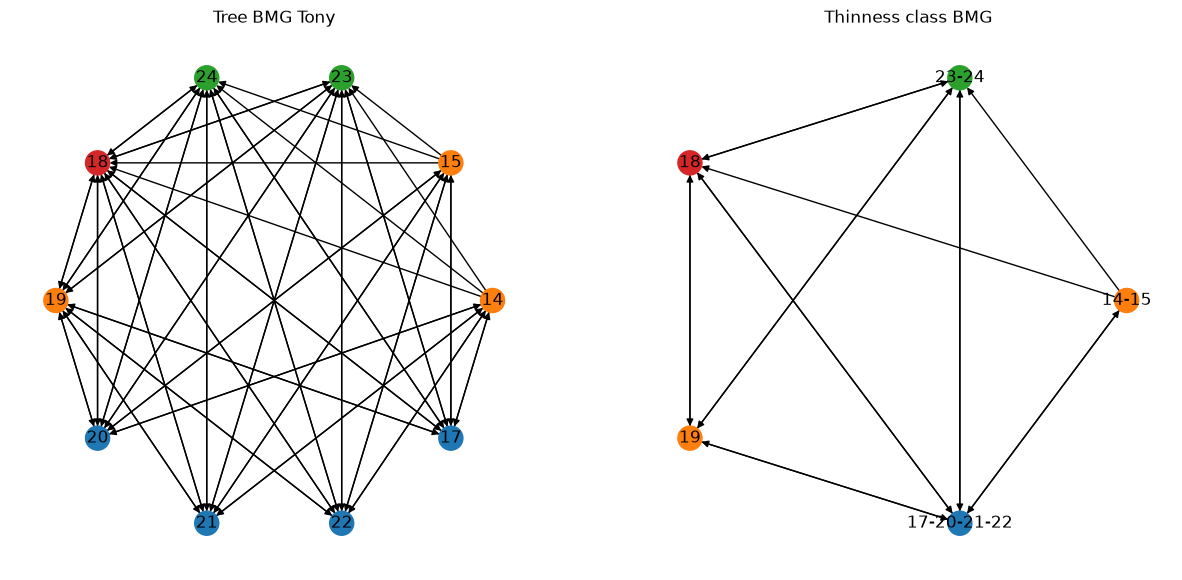

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
nodes_list = [v for v in BMG_tree_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_tree_tony, nx.circular_layout(BMG_tree_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree BMG Tony")

# thinness BMG
nodes_list = [v for v in thin_BMG.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_BMG, nx.circular_layout(thin_BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class BMG")

In [42]:
# BMG
G = thin_BMG.copy()
# initialize Bic Cherry
N = nx.DiGraph()
curr_root_num = 0
curr_root = "rho" + f"_{curr_root_num}"
N.add_node(curr_root)

# create a color to node dict
color_to_leaves = {}
for v in G.nodes:
    key = (
        G.nodes[v]["color"]
    )
    color_to_leaves.setdefault(key, []).append(v)

# test if any node in the BMG exists that has every other node as a reciprocal best match
leaves = G.nodes()
leaves_to_remove = []
att_to_root = False
for leaf in leaves:
    suc = frozenset(G.successors(leaf))
    prec = frozenset(G.predecessors(leaf))
    if ((suc == prec) and (suc == leaves-[leaf])):
        print(f"found {leaf}")
        N.add_edge(curr_root, leaf)
        leaves_to_remove.append(leaf)
        att_to_root = True
G.remove_nodes_from(leaves_to_remove)
if att_to_root:
    curr_root_num += 1
    curr_root = "rho" + f"_{curr_root_num}"

# test if any node in BMG exists that has no incoming edges (pred) and another node of the same color exists
leaves = G.nodes()
leaves_to_remove = []
att_to_root = False
for leaf in leaves:
    cur_color = G.nodes[leaf]["color"]
    prec = frozenset(G.predecessors(leaf))
    if ((len(prec) == 0) and (len(color_to_leaves[cur_color]) > 1)):
        print(f"found {leaf}")
        N.add_edge(curr_root, leaf)
        leaves_to_remove.append(leaf)
        att_to_root = True
G.remove_nodes_from(leaves_to_remove)
if att_to_root:
    curr_root_num += 1
    curr_root = "rho" + f"_{curr_root_num}"

# reattach all roots
for i in range(curr_root_num):
    N.add_edge("rho" + f"_{i}", "rho" + f"_{i+1}")
    


found 17-20-21-22
found 14-15
0
1


Text(0.5, 1.0, 'Thinness class BMG')

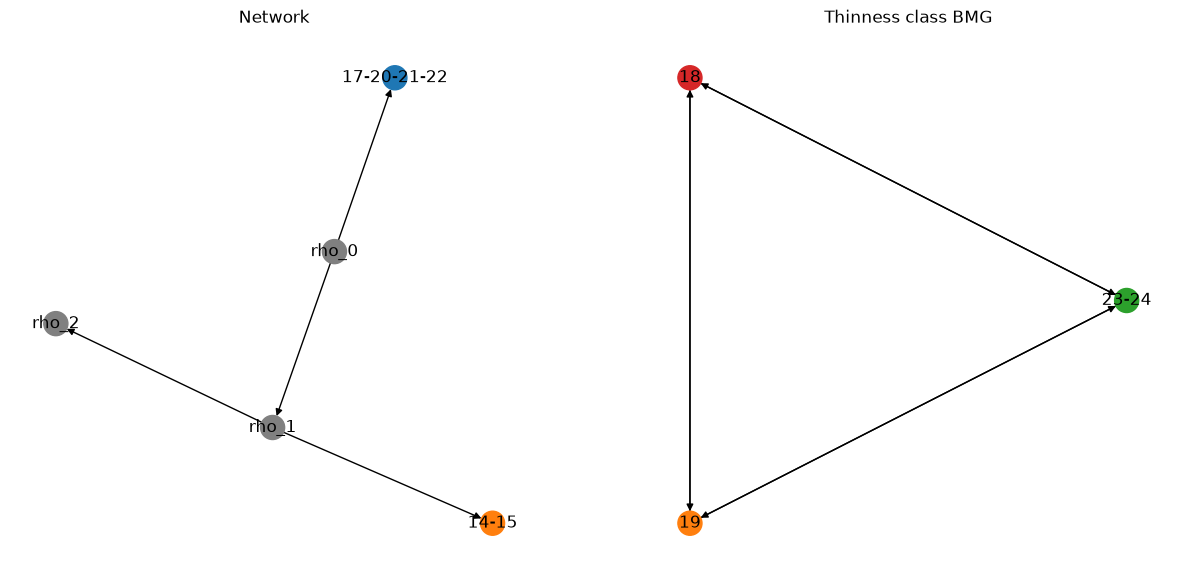

In [44]:
# visualization

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
nodes_list = [v for v in N.nodes()]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(N, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Network")

# thinness BMG
nodes_list = [v for v in G.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(G, nx.circular_layout(G), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class BMG")

found 17-20-21-22
found 14-15
edges left in G:  [('23-24', '19'), ('23-24', '18'), ('18', '19'), ('18', '23-24'), ('19', '23-24'), ('19', '18')]
Cherrylist:  [frozenset({'18', '23-24'}), frozenset({'18', '19'}), frozenset({'19', '23-24'})]


Text(0.5, 1.0, 'New Bic Cherry')

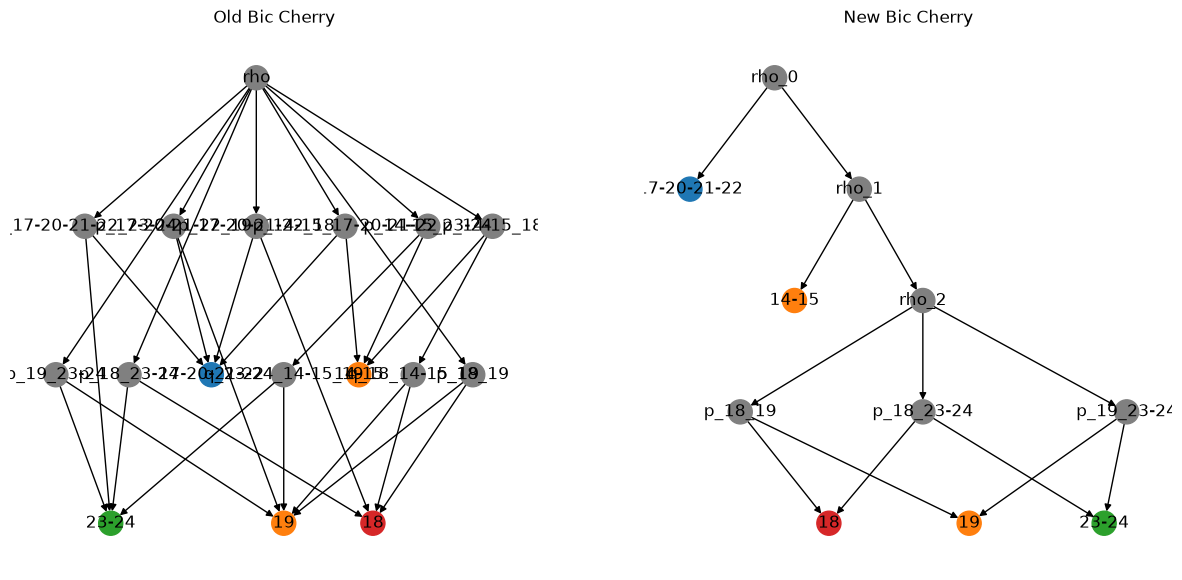

In [4]:
from BICcherry_test import BICcherry_test
from BICcherryRestrict import BICcherryRestrict
old_bic_cherry = BICcherryRestrict(thin_BMG)
new_bic_cherry = BICcherry_test(thin_BMG)

# visualization

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
pos = graphviz_layout(old_bic_cherry, prog="dot")
nodes_list = [v for v in old_bic_cherry.nodes()]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(old_bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Old Bic Cherry")

# thinness BMG
pos = graphviz_layout(new_bic_cherry, prog="dot")
nodes_list = [v for v in new_bic_cherry.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(new_bic_cherry, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("New Bic Cherry")

Is the new bic cherry BMG equal to the original?  True


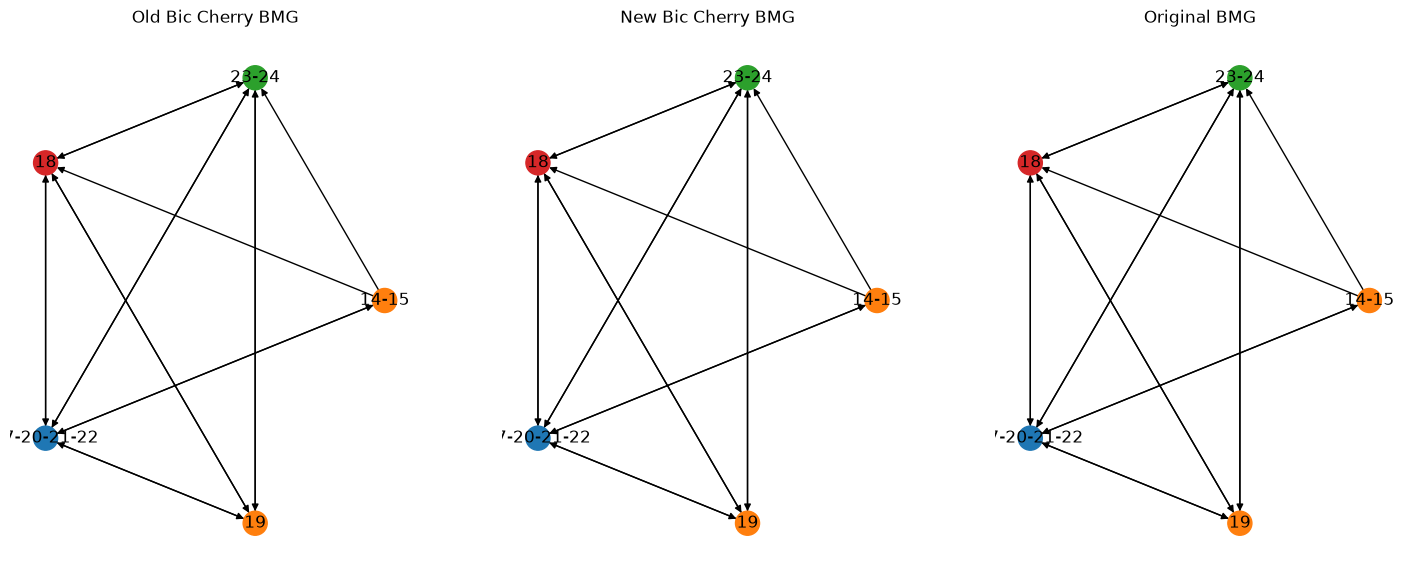

In [7]:
# compare BMGs of both BicCherries
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Nach Tonys Funktion
old_bic_cherry_BMG = bmg(old_bic_cherry)
pos = nx.circular_layout(old_bic_cherry_BMG)
nodes_list = [v for v in old_bic_cherry_BMG.nodes()]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(old_bic_cherry_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Old Bic Cherry BMG")

# thinness BMG
new_bic_cherry_BMG = bmg(new_bic_cherry)
nodes_list = [v for v in new_bic_cherry_BMG.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(new_bic_cherry_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("New Bic Cherry BMG")

# thinness BMG
nodes_list = [v for v in thin_BMG.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[2], with_labels=True)
axes[2].set_title("Original BMG")

print("Is the new bic cherry BMG equal to the original? ", nx.utils.graphs_equal(new_bic_cherry_BMG, thin_BMG))

In [12]:
test = nx.Graph()
test.add_edge('a','b')
test.add_edge('c','d')
comps = list(nx.connected_components(test))
for C in comps:
    print(C)

{'b', 'a'}
{'d', 'c'}
